detrのデモ

In [2]:
"""
DETR (DEtection TRansformer) with MS_COCO 2014
"""
import os
import sys
import glob
from typing import (
    Callable,
    Sequence,
    Tuple,
    Union,
    List,
    Dict,
    Optional,
)
import json
import math
import shutil
from pathlib import Path
import random
from collections import deque

import numpy as np
from scipy.optimize import linear_sum_assignment # ハンガリアンアルゴリズム
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch.nn.utils import clip_grad_norm
from tqdm import tqdm

# torch
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torch import optim

# torchvision
import torchvision
from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.utils import (
    draw_bounding_boxes,
    draw_keypoints,
    draw_segmentation_masks,
)
from torchvision.ops import (
    sigmoid_focal_loss,
    batched_nms,
)
from torchvision.ops.misc import FrozenBatchNorm2d

# MS_COCO
from pycocotools.cocoeval import COCOeval

# My libs
from utils import (
    post_process,
)

from dataset import (
    Compose,
    RandomHorizontalFlip,
    RandomResize,
    RandomSelect,
    RandomSizeCrop,
    ToTensor,
    Normalize,
    CocoDetectionDataset,
    collate_func,
    generate_subset,
    SubsetRandomSampler,
)

from loss import loss_func

from arch import DETR

In [3]:
# 外付けSSD
IMG_OBJECT_DETECTION_PATH: str = "F:\\MS_COCO\\2014\\tasks\\object_detection"

# 内部PC
MODEL_FILE_PATH: str = os.path.join(os.getcwd(), "model", "detr.pth")

In [4]:
class ConfigDemo:
    '''
    ハイパーパラメータとオプションの設定
    '''
    def __init__(self):
        self.img_directory = IMG_OBJECT_DETECTION_PATH # 画像があるディレクトリ
        self.load_file = MODEL_FILE_PATH       # 学習済みパラメータのパス
        self.classes = ['person', 'car']       # 検出対象の物体クラス
        self.num_queries = 100                 # 物体クエリ埋め込みのクエリベクトル数
        self.dim_hidden = 256                  # Transformer内の特徴量次元
        self.num_heads = 8                     # マルチヘッドアテンションのヘッド数
        self.num_encoder_layers = 6            # Transformerエンコーダの層数
        self.num_decoder_layers = 6            # Transformerデコーダの層数
        self.dim_feedforward = 2048            # Transformer内のFNNの中間特徴量次元
        self.dropout = 0.1                     # Transformer内のドロップアウト率
        self.device = 'cuda'                   # デモに使うデバイス

In [11]:
def demo():
    config = ConfigDemo()

    transforms = Compose((
        RandomResize((608,), max_size=1024),
        ToTensor(),
        Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ))

    # 学習済みモデルの読み込み
    model = DETR(config.num_queries,
                 config.dim_hidden,
                 config.num_heads,
                 config.num_encoder_layers,
                 config.num_decoder_layers,
                 config.dim_feedforward,
                 config.dropout,
                 len(config.classes))

    model.load_state_dict(torch.load(config.load_file))
    model.to(config.device)
    model.eval()

    for img_path in Path(config.img_directory).iterdir():
        img_orig = Image.open(img_path)
        width, height = img_orig.size

        # データ整形を適用するためにダミーのラベルを用意
        target = {
            'classes': torch.zeros((0,), dtype=torch.int64),
            'boxes': torch.zeros((0, 4), dtype=torch.float32),
            'size': torch.tensor((width, height), dtype=torch.int64),
            'orig_size': torch.tensor((width, height), dtype=torch.int64)
        }

        # データ整形
        img, target = transforms(img_orig, target)
        imgs, masks, targets = collate_func([(img, target)])

        with torch.no_grad():
            imgs = imgs.to(model.get_device())
            masks = masks.to(model.get_device())
            targets = [{ k: v.to(model.get_device()) for k, v in target.items()}
                       for target in targets]

            preds_class, preds_box = model(imgs, masks)

            scores, labels, boxes = post_process(preds_class[-1],
                                                 preds_box[-1],
                                                 targets,
                                                 include_bg=True)
            print('背景ラベル', len(config.classes))
            print("scores", scores)
            print("labels", labels)
            print("boxes", boxes)


            # 背景クラスに分類された矩形を除外
            boxes = boxes[0, labels[0] != len(config.classes)]
            labels = labels[0, labels[0] != len(config.classes)]

            # 描画用の画像を用意
            img = torch.tensor(np.asarray(img_orig))
            img = img.permute(2, 0, 1)

            # クラスIDをクラス名に変換
            labels = [config.classes[label] for label in labels]

            # 矩形を描画
            img = draw_bounding_boxes(
                img, boxes, labels, colors="red",
                # font="LiberationSans-Regular.ttf",
                font_size=42, width=4)
            img = img.permute(1,2,0)
            img = img.to("cpu").numpy()
            img = Image.fromarray(img)
            # plt.imshow(img)
            # img.show()
            display(img)

    # plt.show()

C:\Users\inoue\AppData\Local\Temp\ipykernel_8520\2792032756.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config.load_file))


背景ラベル 2
scores tensor([[0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981, 0.9981,
         0.9981]], device='cuda:0')
labels tensor([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

c:\Users\inoue\miniconda3_inoue_py311\envs\AIWorkPy311Env\Lib\site-packages\torchvision\utils.py:211: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")


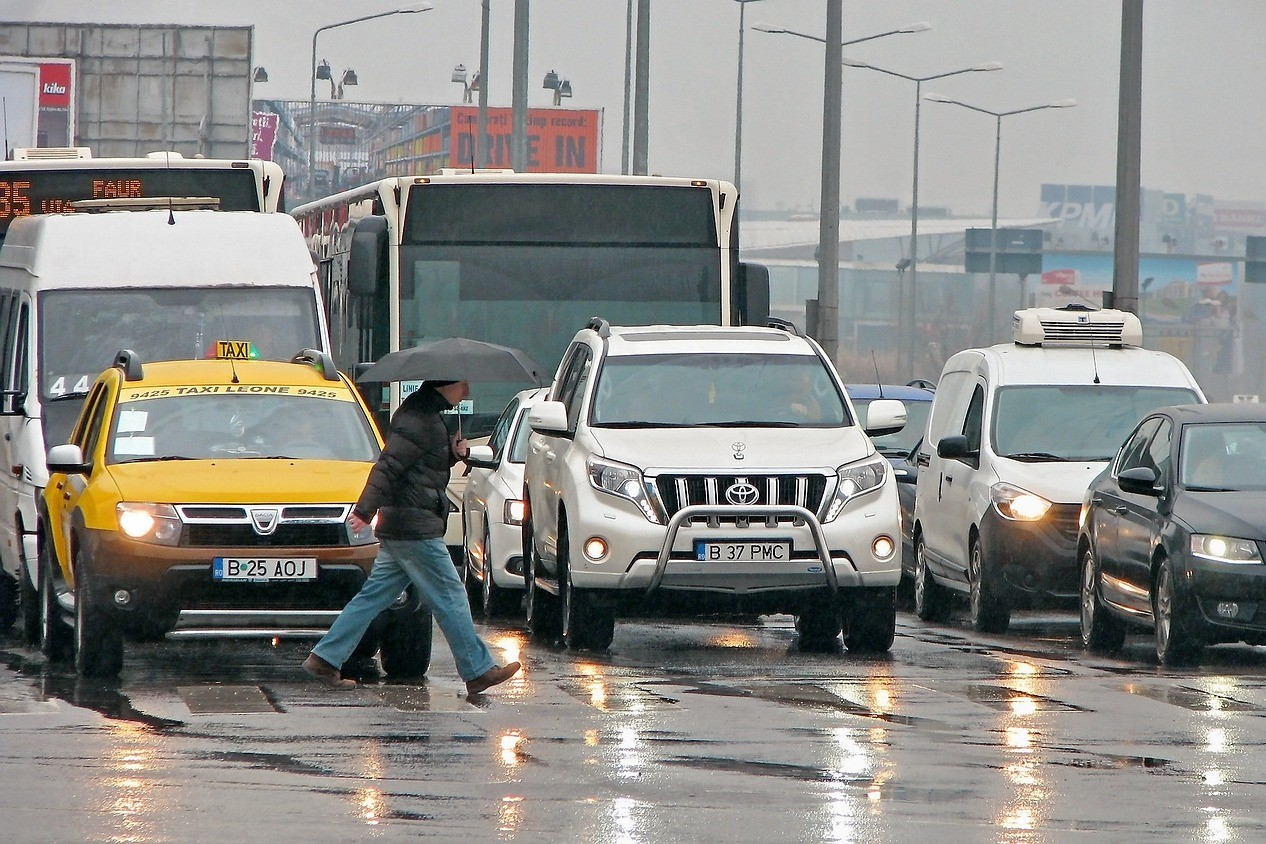

背景ラベル 2
scores tensor([[0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967, 0.9967,
         0.9967]], device='cuda:0')
labels tensor([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

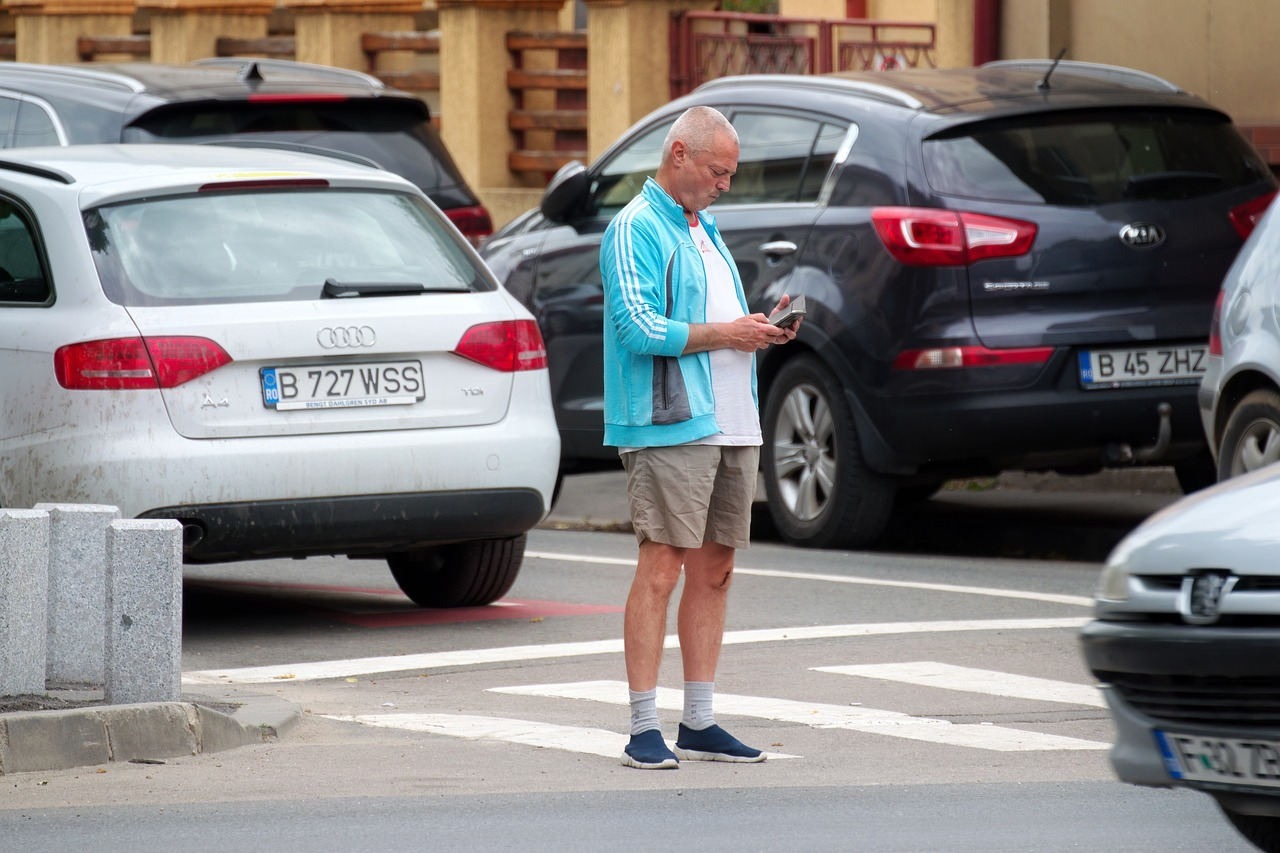

背景ラベル 2
scores tensor([[0.9927, 0.9928, 0.9928, 0.9927, 0.9927, 0.9927, 0.9928, 0.9927, 0.9927,
         0.9927, 0.9928, 0.9928, 0.9927, 0.9927, 0.9927, 0.9928, 0.9927, 0.9927,
         0.9928, 0.9928, 0.9927, 0.9927, 0.9927, 0.9927, 0.9927, 0.9927, 0.9928,
         0.9928, 0.9927, 0.9927, 0.9927, 0.9928, 0.9927, 0.9927, 0.9927, 0.9928,
         0.9927, 0.9927, 0.9928, 0.9927, 0.9927, 0.9927, 0.9927, 0.9928, 0.9928,
         0.9927, 0.9928, 0.9927, 0.9928, 0.9927, 0.9927, 0.9927, 0.9927, 0.9927,
         0.9928, 0.9927, 0.9928, 0.9928, 0.9927, 0.9927, 0.9927, 0.9927, 0.9928,
         0.9927, 0.9928, 0.9927, 0.9928, 0.9928, 0.9927, 0.9927, 0.9927, 0.9928,
         0.9927, 0.9927, 0.9927, 0.9927, 0.9927, 0.9927, 0.9928, 0.9927, 0.9927,
         0.9927, 0.9927, 0.9927, 0.9928, 0.9927, 0.9927, 0.9927, 0.9928, 0.9927,
         0.9927, 0.9928, 0.9927, 0.9927, 0.9927, 0.9927, 0.9927, 0.9927, 0.9928,
         0.9928]], device='cuda:0')
labels tensor([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

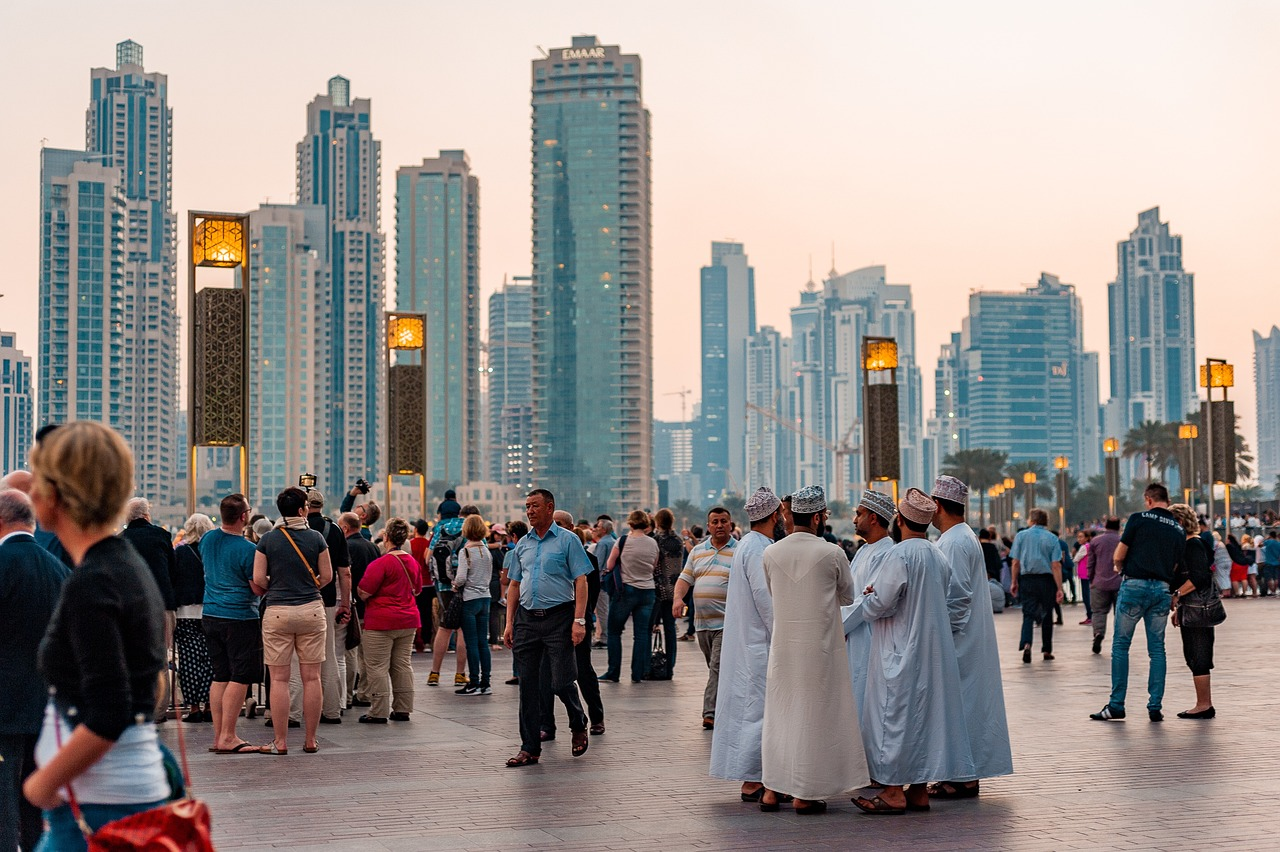

背景ラベル 2
scores tensor([[0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
         0.9935]], device='cuda:0')
labels tensor([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

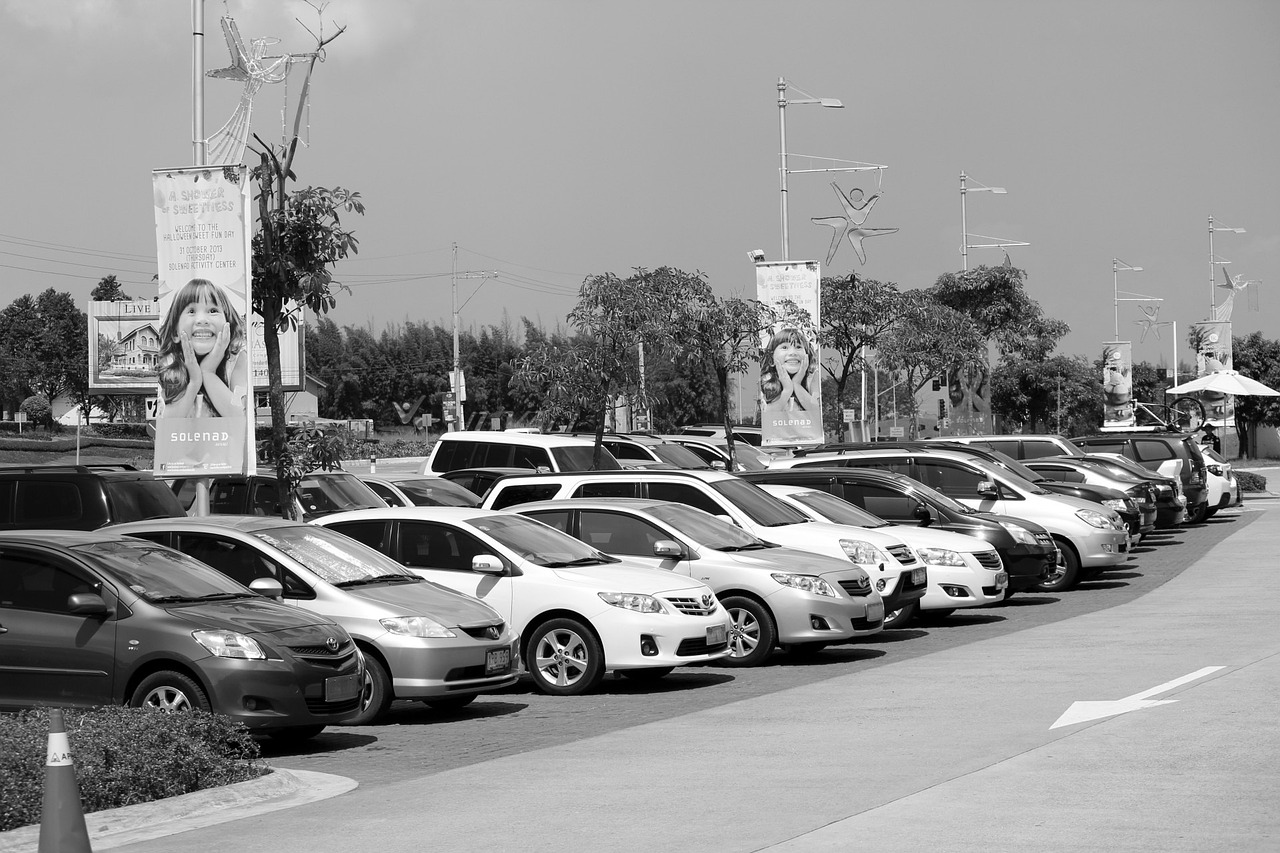

In [12]:
demo()